In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Método impedancia por groove

In [ ]:
# SISTEMA CGS
#-------------------------------------- DEPENDEN DEL SETUP PARA ONDAS DE SPIN
n_grooves = 12
H0 = 770 #[Oe]
#-------------------------------------- CONSTANTES
gamma = 2.8 #[MHz/Oe]
mu0 = 1
Ms = 1750 #[G]
omega0 = 2*np.pi*np.abs(gamma)*H0/1000
omegaM = 2*np.pi*np.abs(gamma)*Ms/1000
deltaH = 0.5 #[Oe]

#-------------------------------------- MEDIDAS DEL CRISTAL (micrómetros)

dPF = 8.3
delta = 1
dG = dPF - delta

LPF = 330
LG = 70

GAMMA = delta/(2*dPF-delta)

#-------------------------------------- DEFINICIÓN DE PARÁMETROS Y MATRICES

def numero_de_onda(w,dj):
    k = -np.log(1+4*(omega0*(omega0+omegaM)-w**2)/(omegaM**2))/(2*dj)
    return k

def numero_de_onda_prim(vgj):
    k = 2*np.pi*np.abs(gamma)*deltaH/((np.abs(vgj))*1000)
    return k

def velocidad_de_grupo(w,dj, kj):
    v = (omegaM**2)*dj*np.exp(-2*kj*dj)/(4*w)
    return v

def P(kj, kj_prim, Lj):
    M = np.array([[np.exp(-(1j*kj-kj_prim)*Lj), 0],[0, np.exp((1j*kj-kj_prim)*Lj)]])
    return M

def D(nu):
    M = np.array([[1, nu*GAMMA],[nu*GAMMA, 1]])/(1-nu*GAMMA)
    return M


In [ ]:
def matriz_de_transferencia(w):
    # parámetros
    k_PF = numero_de_onda(w, dPF)
    k_G = numero_de_onda(w,dG)

    vg_PF = velocidad_de_grupo(w,dPF, k_PF)
    vg_G = velocidad_de_grupo(w,dG,k_G)

    k_PF_prim = numero_de_onda_prim(vg_PF)
    k_G_prim = numero_de_onda_prim(vg_G)

    #matrices individuales
    P_PF = P(k_PF, k_PF_prim, LPF)
    P_G = P(k_G, k_G_prim, LG)

    D_mas = D(1)
    D_menos = D(-1)

    #matriz de transferencia
    T = P_PF @ D_mas @ P_G @ D_menos

    #matriz de transferencia total
    M = np.linalg.matrix_power(T, n_grooves)

    # escoger la entrada 1,1 (Potencia de transmisión)
    transmision = 1/np.abs(M[0,0]**2)

    return transmision

# Para encontrar la transmisión --------------------------------------------

frecuencias = np.linspace(3.9*2*np.pi, 4.5*2*np.pi, 1000)
Transmisiones = np.zeros(len(frecuencias))

for i in range(len(frecuencias)):
    Transmisiones[i] = 10 * np.log10(matriz_de_transferencia(frecuencias[i]))

# Para guardar el valor de las frecuencias prohibidas ----------------------

prohibidas = [] # en GHz
indice_prohibidas = []

tol = 0.01

for i in range(2,len(Transmisiones)-2):
    if Transmisiones[i-1] > Transmisiones[i]:
        if Transmisiones[i] < Transmisiones[i+1]:
            if np.abs(Transmisiones[i]-Transmisiones[i-2]) > tol:
                prohibidas.append(frecuencias[i]/(2*np.pi))
                indice_prohibidas.append(i+2)

#plt.figure(figsize=(7, 5))
#plt.plot(frecuencias/(2*np.pi), Transmisiones, color = 'red')
#for i in range(len(prohibidas)):
#    plt.axvline(x=prohibidas[i], color='lightsteelblue', linestyle='--')
#plt.xlim(3.9, 4.55)
#plt.ylim(Transmisiones[-1], -2)
#plt.title('Espectro del YIG')
#plt.xlabel('Frecuencia [GHz]')
#plt.ylabel('Transmisión [dB]')
#plt.grid(color='lightgrey')
#plt.show()

In [ ]:
# Para encontrar el número de onda -----------------------------
ks = numero_de_onda(frecuencias,dPF)*(2*np.pi)*1e3

#plt.figure(figsize=(7, 5))
#plt.plot(ks, frecuencias/(2*np.pi))
#plt.xlabel('k [rad/cm]')
#plt.ylabel('Frecuencia [GHz]')
#plt.title('Número de onda')
#plt.grid(color='lightgrey')
#plt.ylim(3.9, 4.55)
#plt.xlim(ks[0], ks[-1])
#for i in range(len(prohibidas)):
#    plt.axhline(y=prohibidas[i], color='lightsteelblue', linestyle='--')
#    plt.axvline(x=ks[indice_prohibidas[i]], color='rosybrown', linestyle='--')
#plt.show()

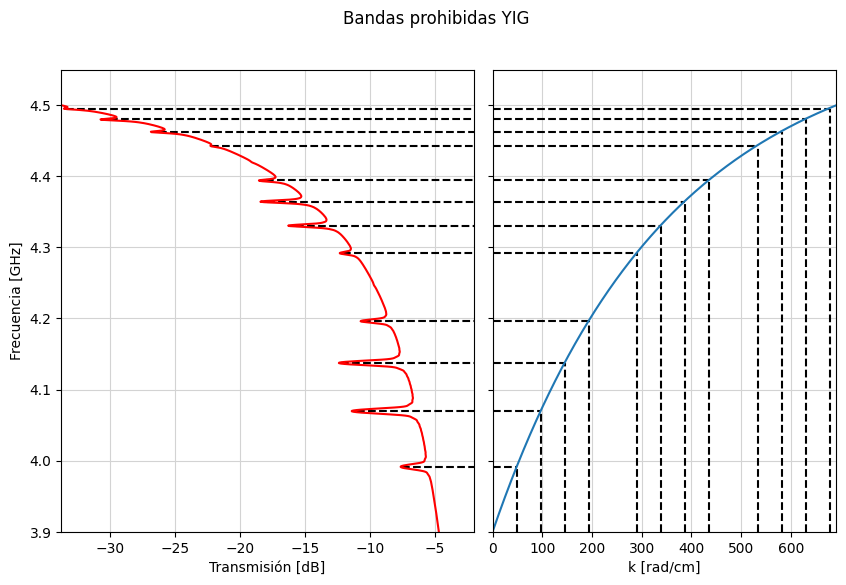

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True,gridspec_kw={'width_ratios': [1.2, 1]}, figsize=(10, 6))

for i in range(len(prohibidas)):
    ax1.hlines(y=prohibidas[i], xmin = Transmisiones[indice_prohibidas[i]], xmax = 0, color='black', linestyle='--')
ax1.plot(Transmisiones, frecuencias/(2*np.pi), color = 'red')
ax1.set_ylim(3.9, 4.55)
ax1.set_xlim(Transmisiones[-1], -2)
ax1.set_ylabel('Frecuencia [GHz]')
ax1.set_xlabel('Transmisión [dB]')
ax1.grid(color='lightgrey')

for i in range(len(prohibidas)):
    ax2.hlines(y=prohibidas[i], xmin = 0, xmax = ks[indice_prohibidas[i]], color='black', linestyle='--')
    plt.vlines(x=ks[indice_prohibidas[i]], ymin = 3.9, ymax = prohibidas[i], color='black', linestyle='--')
ax2.plot(ks, frecuencias/(2*np.pi))
ax2.set_xlabel('k [rad/cm]')
ax2.grid(color='lightgrey')
ax2.set_ylim(3.9, 4.55)
ax2.set_xlim(ks[0], ks[-1])

plt.suptitle('Bandas prohibidas YIG')
plt.subplots_adjust(wspace=0.05)
plt.show()

# Método impedancia por temperatura

In [ ]:
# SISTEMA CGS

H0 = 770 #[Oe]
gamma = 2.8e-3 #[GHz/Oe]
deltaH = 0.5 #[Oe]
mu0 = 1

Ms_roomtemp = 1759.3 #[G]
eta = 3.933 #[G/Kelvin]
T_room = 298 #[Kelvin]
T_background = 309 #[Kelvin]
T_max = 350 #[Kelvin]

d = 5e-4 #[cm]
iluminado = 70e-4 # [cm]
obscuro = 330e-4 # [cm]
a = iluminado + obscuro # constante de red [cm]
N_stripes = 12 # número de franjas iluminadas
muestras_a = 20
muestras = muestras_a*N_stripes # número de puntos
dx = a*N_stripes/muestras # tamaño del paso
print(dx*1e4)

width_peak_fraction = iluminado/obscuro   # fracción del periodo para el pico térmico

20.0


In [ ]:
def numero_de_onda(T,w): #[1/cm]
    #wH
    w0 = (2*np.pi)*np.abs(gamma)*H0 #[rad GHz]
    # wM
    M = Ms_roomtemp - eta*(T-T_room)
    wM = gamma*mu0*M *(2*np.pi)#[rad GHz]

    k = -np.log(1+4*(w0*(w0+wM)-w**2)/(wM**2))/(2*dx)
    return k

def GAMMA(kj1,kj):
    return (kj1 - kj)/(kj1 + kj)

def T1(k):
    M = np.array([[np.exp(-(1j*k*dx)), 0],[0, np.exp(1j*k*dx)]])
    return M

def T2(GAMMA):
    M = np.array([[1, GAMMA],[GAMMA, 1]])/(1-GAMMA)
    return M

def matriz_de_transferencia_volume(w,T):
    M = np.eye(2, dtype=complex)
    for i in range(len(T)):
        if i != (len(T)-1):
            kj = numero_de_onda(T[i],w)
            kj1 = numero_de_onda(T[i+1],w)

            G = GAMMA(kj1,kj)

            Prop = T1(kj)
            Trans = T2(G)

            M = Trans @ Prop @ M

        else:
            kj = numero_de_onda(T[i],w)

            Prop = T1(kj)
            M = Prop @ M

    # escoger la entrada 1,1 (Potencia de transmisión)
    transmision = 1/np.abs(M[0,0])**2

    return transmision

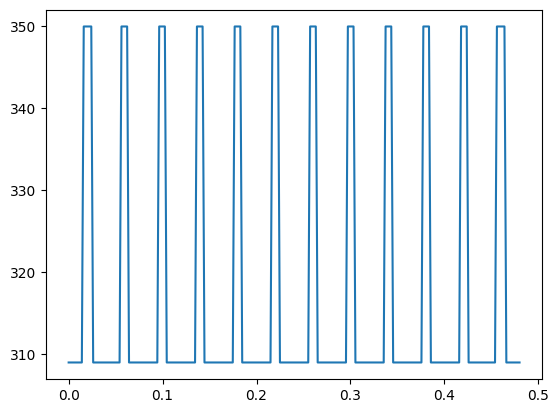

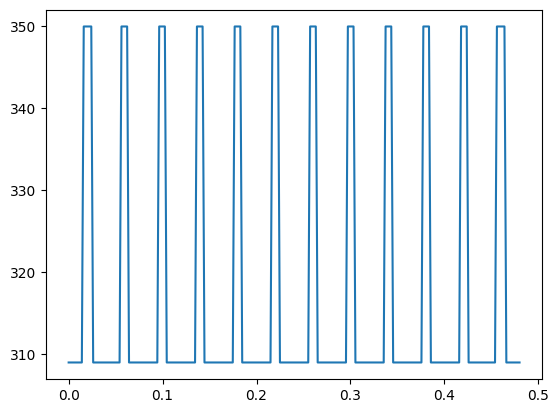

In [ ]:
# Definir la temperatura

z_total = a * N_stripes
z = np.linspace(0, z_total, muestras)
centro = a/2
mitad_pico = (width_peak_fraction * a)/2

T = np.zeros_like(z)

for i in range(len(z)):
    # posición dentro del periodo
    pos_in_period = z[i] % a
    if np.abs(pos_in_period - centro) <= mitad_pico:
        T[i] = T_max
    else:
        T[i] = T_background

plt.plot(z,T)
plt.show()

from scipy.ndimage import gaussian_filter1d
#T= gaussian_filter1d(T, sigma=1)

plt.plot(z,T)
plt.show()

/tmp/ipykernel_5727/1850919173.py:8: RuntimeWarning: invalid value encountered in log
  k = -np.log(1+4*(w0*(w0+wM)-w**2)/(wM**2))/(2*dx)


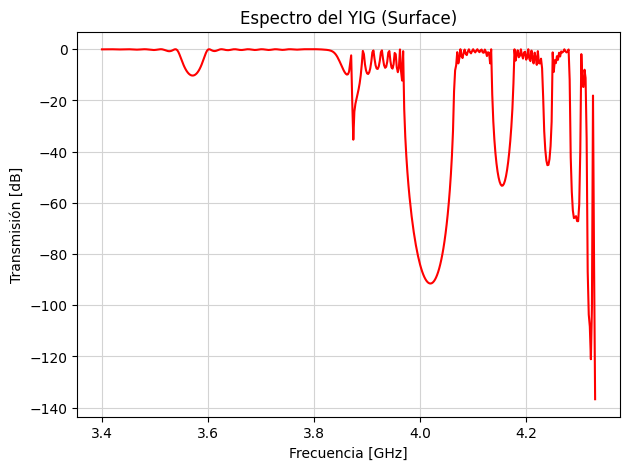

In [ ]:
# Para encontrar la transmisión --------------------------------------------

frecuencias = np.linspace(3.4*2*np.pi, 5.4*2*np.pi, 1000)
Transmisiones = np.zeros(len(frecuencias))

for i in range(len(frecuencias)):
    Transmisiones[i] = 10 * np.log10(matriz_de_transferencia_volume(frecuencias[i],T))

plt.figure(figsize=(7, 5))
plt.plot(frecuencias/(2*np.pi), Transmisiones, color = 'red')
plt.title('Espectro del YIG (Surface)')
plt.xlabel('Frecuencia [GHz]')
plt.ylabel('Transmisión [dB]')
plt.grid(color='lightgrey')
plt.show()

# Método impedancia por temperatura (Volume)

In [ ]:
# SISTEMA CGS

H0 = 1797 #[Oe]
gamma = 2.8e-3 #[GHz/Oe]
deltaH = 0.5 #[Oe]
mu0 = 1

Ms_roomtemp = 1759.3 #[G]
eta = 3.933 #[G/Kelvin]
T_room = 298 #[Kelvin]
T_background = 309 #[Kelvin]
T_max = 335 #[Kelvin]

d = 5e-4 #[cm]
iluminado = 50e-4 # [cm]
obscuro = 420e-4 # [cm]
a = iluminado + obscuro # constante de red [cm]
N_stripes = 5 # número de franjas iluminadas
muestras_a = 20
muestras = muestras_a*N_stripes # número de puntos
dx = a*N_stripes/muestras # tamaño del paso
print(dx*1e4)

width_peak_fraction = iluminado/obscuro   # fracción del periodo para el pico térmico

23.499999999999996


In [ ]:
def numero_de_onda(T,w): #[1/cm]
    #wH
    wH = gamma*mu0*H0 *(2*np.pi)#[rad GHz]
    # wM
    M = Ms_roomtemp - eta*(T-T_room)
    wM = gamma*mu0*M *(2*np.pi)#[rad GHz]
    #wani
    wani = 0
    # wFMR
    wFMR = np.sqrt(wH*(wH+wM-wani))#[rad GHz]
    # vg
    vg = -(wH*wM*d)/(4*wFMR) #[rad m/GHz]
    # k
    k = (w-wFMR)/vg
    return k

def GAMMA(kj1,kj):
    return (kj1 - kj)/(kj1 + kj)

def T1(k):
    M = np.array([[np.exp(-(1j*k*dx)), 0],[0, np.exp(1j*k*dx)]])
    return M

def T2(GAMMA):
    M = np.array([[1, GAMMA],[GAMMA, 1]])/(1-GAMMA)
    return M

def matriz_de_transferencia_volume(w,T):
    M = np.eye(2, dtype=complex)
    for i in range(len(T)):
        if i != (len(T)-1):
            kj = numero_de_onda(T[i],w)
            kj1 = numero_de_onda(T[i+1],w)

            G = GAMMA(kj1,kj)

            Prop = T1(kj)
            Trans = T2(G)

            M = Trans @ Prop @ M

        else:
            kj = numero_de_onda(T[i],w)

            Prop = T1(kj)
            M = Prop @ M

    # escoger la entrada 1,1 (Potencia de transmisión)
    transmision = 1/np.abs(M[0,0])**2

    return transmision

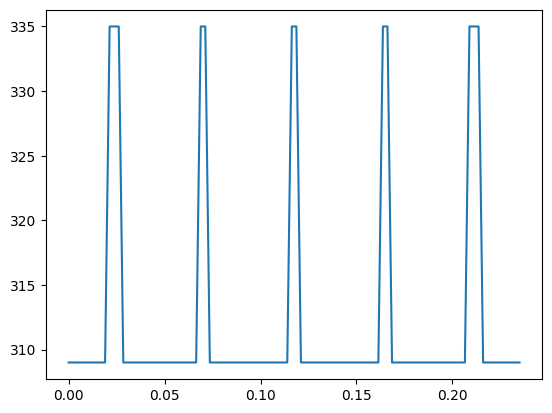

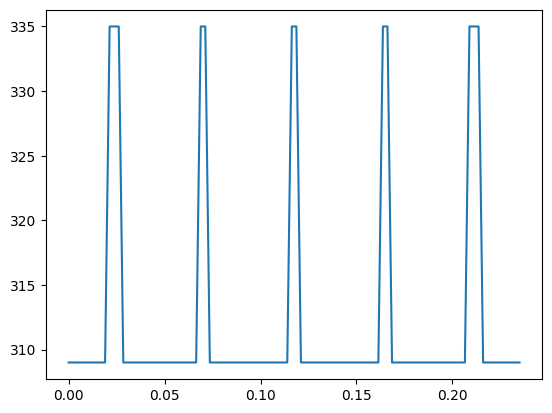

In [ ]:
# Definir la temperatura

z_total = a * N_stripes
z = np.linspace(0, z_total, muestras)
centro = a/2
mitad_pico = (width_peak_fraction * a)/2

T = np.zeros_like(z)

for i in range(len(z)):
    # posición dentro del periodo
    pos_in_period = z[i] % a
    if np.abs(pos_in_period - centro) <= mitad_pico:
        T[i] = T_max
    else:
        T[i] = T_background

plt.plot(z,T)
plt.show()

from scipy.ndimage import gaussian_filter1d
#T= gaussian_filter1d(T, sigma=1)

plt.plot(z,T)
plt.show()

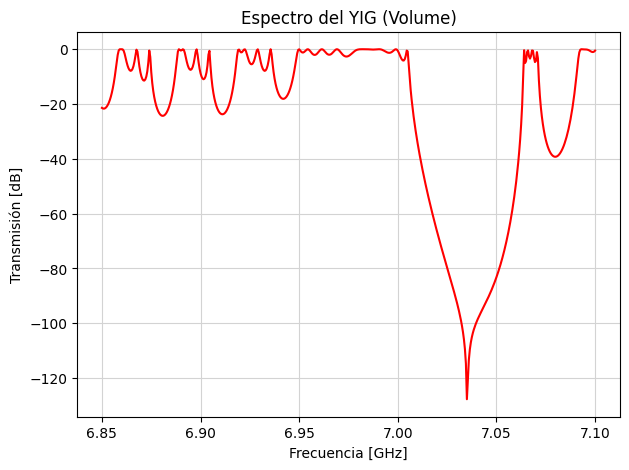

In [ ]:
# Para encontrar la transmisión --------------------------------------------

frecuencias = np.linspace(6.85*2*np.pi, 7.10*2*np.pi, 501)
Transmisiones = np.zeros(len(frecuencias))

for i in range(len(frecuencias)):
    Transmisiones[i] = 10 * np.log10(matriz_de_transferencia_volume(frecuencias[i],T))

plt.figure(figsize=(7, 5))
plt.plot(frecuencias/(2*np.pi), Transmisiones, color = 'red')
plt.title('Espectro del YIG (Volume)')
plt.xlabel('Frecuencia [GHz]')
plt.ylabel('Transmisión [dB]')
plt.grid(color='lightgrey')
plt.show()